# Nesso-1 on the FEP+ four-kinase benchmark

This notebook is an accessible, executable walkthrough of experiment `exp007_fepplus4_boltz2_nesso1`. It uses the **87 predictions already generated** by Nesso-1 and reconstructs the analysis in the weekly report.

We will answer four questions:

1. What is one target series and what does $N$ mean?
2. How do predicted affinity scores compare with IC50 or Ki measurements?
3. What do Pearson, Spearman, Kendall, MAE, and centered MAE measure?
4. How do the four target-level results produce the reported aggregate score?

> **Scope:** these labels are biochemical potency measurements, not rigorous equilibrium binding free energies. The notebook analyzes existing outputs; it does not automatically launch GPU inference.

## 1. Analysis workflow

For each target, the protein construct stays fixed while the ligand changes:

`protein sequence(s) + ligand SMILES -> Nesso-1 -> one continuous affinity score`

We pair every prediction with the experimental measurement for the same immutable `sample_id`. Metrics are calculated **separately within CDK2, TYK2, JNK1, and p38**. Only then are target-level results combined. This avoids treating measurements from unrelated assays as if they were one common calibrated experiment.

In [1]:
from pathlib import Path
import csv
import json
import math
import shlex
import sys
import warnings

warnings.filterwarnings('ignore', message='Pandas requires version')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Find the repository root whether Jupyter started in the root or notebooks/.
ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'experiments').is_dir() and (candidate / 'src').is_dir():
        ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not locate the BindingAffinityPredictor repository root')

sys.path.insert(0, str(ROOT / 'src'))
from affinity_benchmark.metrics.affinity_regression import (
    assay_metrics,
    compound_weighted_average,
    log10_micromolar_to_kcal_per_mol,
)

plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root:', ROOT)

Repository root: /mnt/hdd2/BindingAffinityPredictor


In [2]:
MANIFEST_PATH = ROOT / 'data/manifests/fepplus4_87.json'
PREDICTIONS_PATH = ROOT / 'runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed42/predictions.csv'
METRICS_PATH = ROOT / 'reports/exp007_fepplus4_boltz2_nesso1/nesso1_metrics.json'

for path in (MANIFEST_PATH, PREDICTIONS_PATH, METRICS_PATH):
    if not path.exists():
        raise FileNotFoundError(f'Missing required experiment artifact: {path}')

manifest = json.loads(MANIFEST_PATH.read_text())
predictions = pd.read_csv(PREDICTIONS_PATH).set_index('sample_id', drop=False)
saved_metrics = json.loads(METRICS_PATH.read_text())

rows = []
for sample in manifest['samples']:
    prediction = predictions.loc[sample['sample_id']]
    chains = sample['protein']['chains']
    rows.append({
        'sample_id': sample['sample_id'],
        'target_id': sample['target_id'],
        'ligand_name': sample['ligand']['name'],
        'smiles': sample['ligand']['input_smiles'],
        'protein_construct': ' + '.join(
            f"{chain['name']} ({chain['sequence_length']} aa)" for chain in chains
        ),
        'reference_pdb': sample['structure_reference']['pdb_id'],
        'endpoint': sample['measurement']['type'].upper(),
        'experimental_value': sample['measurement']['value'],
        'experimental_unit': sample['measurement']['unit'],
        'experimental_log10_uM': sample['measurement']['log10_value_uM'],
        'predicted_log10_uM': float(prediction['affinity_pred_value']),
        'binder_probability': float(prediction['affinity_probability_binary']),
        'status': prediction['status'],
    })

data = pd.DataFrame(rows)
assert len(data) == 87
assert (data['status'] == 'complete').all()
assert np.isfinite(data[['experimental_log10_uM', 'predicted_log10_uM']]).all().all()
print('Audit passed: 87/87 predictions are complete and finite.')

Audit passed: 87/87 predictions are complete and finite.


## 2. What the benchmark columns mean

- **Target:** the protein whose ligand series is being evaluated. It is not a numerical target supplied to the model.
- **$N$:** the number of distinct ligands paired with that fixed protein construct. One ligand gives one model example and one experimental reference value.
- **Experimental endpoint:** IC50 for CDK2, JNK1, and p38; Ki for TYK2. Lower values mean stronger apparent inhibition. IC50 and Ki are related but not interchangeable.
- **Reference PDB:** the deposited complex used to identify the exact construct. Its coordinates and bound ligand pose were **not** model inputs.
- **Protein construct:** the exact sequence or sequences passed to Nesso. CDK2 includes cyclin A2; JNK1 includes an 11-residue JIP1 peptide.

In [3]:
target_summary = (
    data.groupby('target_id', sort=False)
    .agg(
        N=('sample_id', 'size'),
        experimental_endpoint=('endpoint', 'first'),
        reference_PDB=('reference_pdb', 'first'),
        protein_construct=('protein_construct', 'first'),
    )
)
target_summary

,N,experimental_endpoint,reference_PDB,protein_construct
target_id,,,,
cdk2,16,IC50,1H1Q,CELL DIVISION PROTEIN KINASE 2 (303 aa) + CYCL...
tyk2,16,KI,4GIH,Non-receptor tyrosine-protein kinase TYK2 (302...
jnk1,21,IC50,2GMX,Mitogen-activated protein kinase 8 (370 aa) + ...
p38,34,IC50,3FLY,Mitogen-activated protein kinase 14 (372 aa)


## 3. Inspect one target series

Change `TARGET` to `tyk2`, `jnk1`, or `p38` and rerun the cells below. The table is sorted from experimentally strongest to weakest because lower IC50/Ki means stronger apparent inhibition.

In [4]:
TARGET = 'cdk2'  # choose from: cdk2, tyk2, jnk1, p38
series = data.query('target_id == @TARGET').copy()
series = series.sort_values('experimental_log10_uM')
series[['sample_id', 'ligand_name', 'endpoint', 'experimental_value',
        'experimental_unit', 'experimental_log10_uM', 'predicted_log10_uM',
        'binder_probability']].reset_index(drop=True)

,sample_id,ligand_name,endpoint,experimental_value,experimental_unit,experimental_log10_uM,predicted_log10_uM,binder_probability
0,cdk2_1h1s,lig_1h1s,IC50,0.0054,uM,-2.267606,-0.592454,0.829977
1,cdk2_28,lig_28,IC50,0.0070,uM,-2.154902,-0.603310,0.881306
2,cdk2_29,lig_29,IC50,0.0560,uM,-1.251812,-0.827729,0.897291
3,cdk2_30,lig_30,IC50,0.0630,uM,-1.200659,-0.297637,0.786844
4,cdk2_1oiy,lig_1oiy,IC50,0.0640,uM,-1.193820,-0.284103,0.544705
5,cdk2_1oi9,lig_1oi9,IC50,0.0690,uM,-1.161151,0.026788,0.476382
6,cdk2_32,lig_32,IC50,0.0700,uM,-1.154902,-0.775821,0.794189
7,cdk2_31,lig_31,IC50,0.1000,uM,-1.000000,-0.161090,0.711848
8,cdk2_1oiu,lig_1oiu,IC50,0.2100,uM,-0.677781,0.175807,0.391600
9,cdk2_20,lig_20,IC50,0.4000,uM,-0.397940,0.108027,0.513369


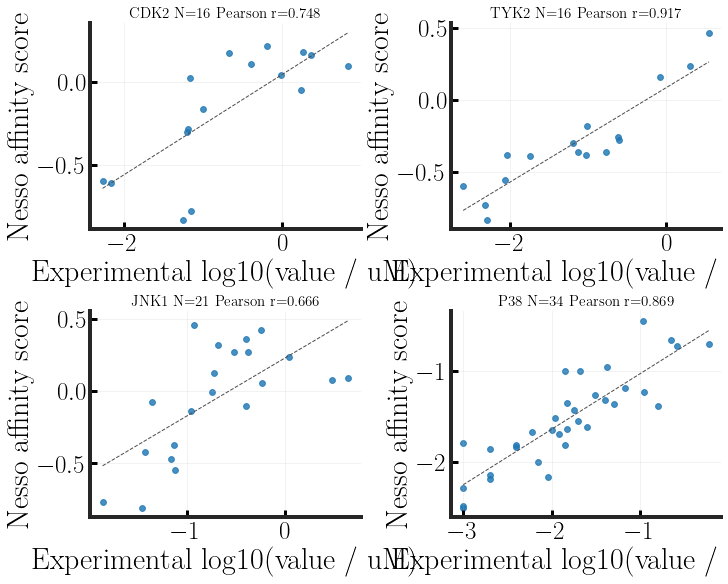

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, target in zip(axes.flat, ['cdk2', 'tyk2', 'jnk1', 'p38']):
    subset = data.query('target_id == @target')
    x = subset['experimental_log10_uM'].to_numpy()
    y = subset['predicted_log10_uM'].to_numpy()
    energy_x = log10_micromolar_to_kcal_per_mol(x)
    energy_y = log10_micromolar_to_kcal_per_mol(y)
    result = assay_metrics(energy_x, energy_y)
    slope, intercept = np.polyfit(x, y, 1)
    domain = np.linspace(x.min(), x.max(), 100)
    ax.scatter(x, y, s=34, alpha=0.82)
    ax.plot(domain, slope * domain + intercept, '--', color='0.3', linewidth=1)
    ax.set_title(f"{target.upper()}  N={len(subset)}  Pearson r={result['pearson_r']:.3f}")
    ax.set_xlabel('Experimental log10(value / uM)')
    ax.set_ylabel('Nesso affinity score')
    ax.grid(alpha=0.2)
plt.show()

## 4. Correlation metrics

For paired experimental values $y_i$ and predictions $\hat y_i$:

- **Pearson $r$** measures linear association. It is unchanged by a constant offset and by positive rescaling.
- **Spearman $\rho$** calculates Pearson correlation after replacing values by ranks. It asks whether the ordering is monotonic.
- **Kendall $\tau$** measures the excess fraction of ligand pairs ordered concordantly rather than discordantly. It is the most directly pairwise ranking statistic.

The Nesso paper used compound-weighted per-target Pearson for FEP+4. Spearman and Kendall below are additional diagnostics; the Nesso paper did not publish corresponding FEP+4 values.

In [6]:
metrics_by_target = {}
for target, subset in data.groupby('target_id', sort=False):
    observed = log10_micromolar_to_kcal_per_mol(subset['experimental_log10_uM'])
    predicted = log10_micromolar_to_kcal_per_mol(subset['predicted_log10_uM'])
    metrics_by_target[target] = assay_metrics(observed, predicted)

per_target_metrics = pd.DataFrame(metrics_by_target).T
per_target_metrics.index.name = 'target'
per_target_metrics[['n', 'pearson_r', 'spearman_rho', 'kendall_tau',
                    'mae_kcal_mol', 'centered_mae_kcal_mol']].round(3)

,n,pearson_r,spearman_rho,kendall_tau,mae_kcal_mol,centered_mae_kcal_mol
target,,,,,,
cdk2,16.0,0.748,0.759,0.550,0.936,0.723
tyk2,16.0,0.917,0.921,0.767,1.212,0.749
jnk1,21.0,0.666,0.667,0.482,0.999,0.450
p38,34.0,0.869,0.894,0.723,0.536,0.425


In [7]:
# Rank 1 is the strongest ligand because lower values indicate stronger inhibition.
rank_view = series[['sample_id', 'experimental_log10_uM', 'predicted_log10_uM']].copy()
rank_view['experimental_rank'] = rank_view['experimental_log10_uM'].rank(method='average')
rank_view['predicted_rank'] = rank_view['predicted_log10_uM'].rank(method='average')
rank_view['absolute_rank_error'] = (rank_view['predicted_rank'] - rank_view['experimental_rank']).abs()
rank_view.sort_values('absolute_rank_error', ascending=False).reset_index(drop=True)

,sample_id,experimental_log10_uM,predicted_log10_uM,experimental_rank,predicted_rank,absolute_rank_error
0,cdk2_32,-1.154902,-0.775821,7.0,2.0,5.0
1,cdk2_1oiu,-0.677781,0.175807,9.0,14.0,5.0
2,cdk2_26,-0.187087,0.216224,11.0,16.0,5.0
3,cdk2_22,0.230449,-0.047112,13.0,8.0,5.0
4,cdk2_17,0.832509,0.099268,16.0,11.0,5.0
5,cdk2_1h1s,-2.267606,-0.592454,1.0,4.0,3.0
6,cdk2_1oi9,-1.161151,0.026788,6.0,9.0,3.0
7,cdk2_29,-1.251812,-0.827729,3.0,1.0,2.0
8,cdk2_20,-0.397940,0.108027,10.0,12.0,2.0
9,cdk2_1h1q,-0.013228,0.044516,12.0,10.0,2.0


## 5. Ordinary and centered MAE

The analysis maps log10 micromolar potency to an energy-like scale at 298.15 K:

$$G_{\mathrm{eff}} = RT\ln(10)\,[\log_{10}(C/\mu\mathrm{M}) - 6].$$

This is a unit transformation, **not proof that IC50 or Ki is a thermodynamic binding free energy**.

Ordinary MAE penalizes every absolute difference. Centered MAE first removes one constant target-specific offset:

$$\mathrm{centered\ MAE}=\frac{1}{N}\sum_i\left| (\hat y_i-\overline{\hat y})-(y_i-\bar y)\right|.$$

It therefore asks whether the model gets the *spacing* between ligands right after one intercept correction. Unlike Pearson, centered MAE still penalizes an incorrect scale.

In [8]:
observed_energy = log10_micromolar_to_kcal_per_mol(series['experimental_log10_uM'])
predicted_energy = log10_micromolar_to_kcal_per_mol(series['predicted_log10_uM'])
mean_signed_offset = float(np.mean(predicted_energy - observed_energy))
ordinary_mae = float(np.mean(np.abs(predicted_energy - observed_energy)))
centered_prediction = predicted_energy - np.mean(predicted_energy) + np.mean(observed_energy)
centered_mae = float(np.mean(np.abs(centered_prediction - observed_energy)))

pd.Series({
    'selected target': TARGET,
    'mean predicted - experimental offset (kcal/mol)': mean_signed_offset,
    'ordinary MAE (kcal/mol)': ordinary_mae,
    'centered MAE (kcal/mol)': centered_mae,
})

selected target                                        cdk2
mean predicted - experimental offset (kcal/mol)    0.716737
ordinary MAE (kcal/mol)                            0.935725
centered MAE (kcal/mol)                            0.723446
dtype: object

## 6. Combining the four targets

The papers do not pool all 87 compounds into one correlation. Instead, they calculate one correlation per target and use the ligand count as a weight:

$$\bar r = \frac{16r_{\mathrm{CDK2}}+16r_{\mathrm{TYK2}}+21r_{\mathrm{JNK1}}+34r_{\mathrm{p38}}}{87}.$$

In [9]:
weighted = {
    metric: compound_weighted_average(metrics_by_target, metric)
    for metric in ['pearson_r', 'spearman_rho', 'kendall_tau',
                   'pairwise_mae_kcal_mol', 'mae_kcal_mol', 'centered_mae_kcal_mol']
}
comparison = pd.DataFrame({
    'our released-checkpoint reproduction': pd.Series(weighted),
    'Nesso paper FEP+4 reference': pd.Series({'pearson_r': 0.80}),
})
comparison.round(4)

,our released-checkpoint reproduction,Nesso paper FEP+4 reference
centered_mae_kcal_mol,0.5454,NaN
kendall_tau,0.6409,NaN
mae_kcal_mol,0.8457,NaN
pairwise_mae_kcal_mol,0.7906,NaN
pearson_r,0.8066,0.8
spearman_rho,0.8192,NaN


In [10]:
# The expensive 2,000-replicate bootstrap was already run with seed 20260817.
bootstrap = saved_metrics['models']['nesso1']['bootstrap_95_percent']
bootstrap_table = pd.DataFrame(bootstrap).T[
    ['lower_95', 'median', 'upper_95', 'iterations_finite', 'seed']
]
bootstrap_table.round(4)

,lower_95,median,upper_95,iterations_finite,seed
pearson_r,0.7308,0.8104,0.8731,2000.0,20260817.0
spearman_rho,0.6949,0.8019,0.8774,2000.0,20260817.0
kendall_tau,0.5411,0.6425,0.7332,2000.0,20260817.0
pairwise_mae_kcal_mol,0.6369,0.7515,0.8702,2000.0,20260817.0
mae_kcal_mol,0.7388,0.8449,0.9603,2000.0,20260817.0
centered_mae_kcal_mol,0.4413,0.5322,0.6251,2000.0,20260817.0


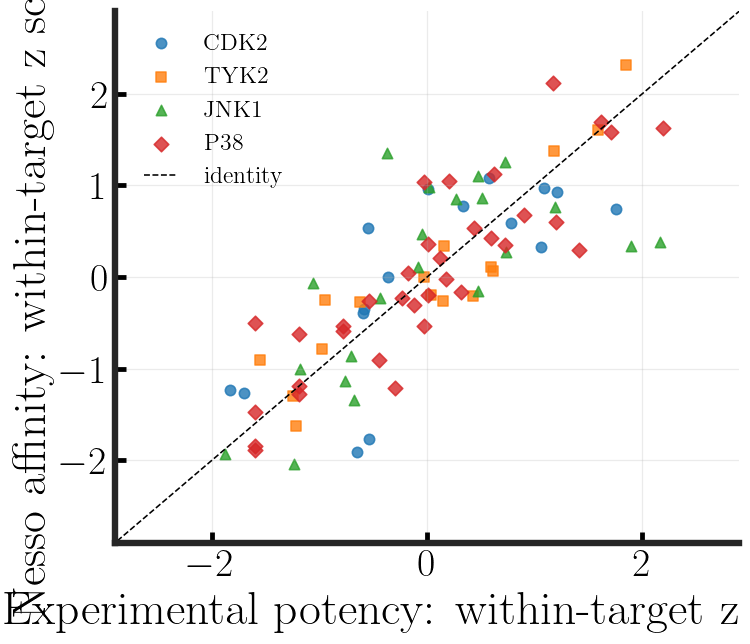

In [11]:
# Reproduce the report's visualization after standardizing within each target.
plot_data = data.copy()
for column, output in [('experimental_log10_uM', 'experimental_z'),
                       ('predicted_log10_uM', 'predicted_z')]:
    plot_data[output] = plot_data.groupby('target_id')[column].transform(
        lambda values: (values - values.mean()) / values.std(ddof=0)
    )

fig, ax = plt.subplots(figsize=(7, 6))
markers = {'cdk2': 'o', 'tyk2': 's', 'jnk1': '^', 'p38': 'D'}
for target, subset in plot_data.groupby('target_id', sort=False):
    ax.scatter(subset['experimental_z'], subset['predicted_z'],
               s=42, alpha=0.8, marker=markers[target], label=target.upper())
ax.plot([-3, 3], [-3, 3], 'k--', linewidth=1, label='identity')
ax.set(xlim=(-2.9, 2.9), ylim=(-2.9, 2.9),
       xlabel='Experimental potency: within-target z score',
       ylabel='Nesso affinity: within-target z score')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.show()

## 7. Native outputs and provenance

Nesso also emits a binary binder probability. It is a different prediction head and must not be mixed with the continuous affinity score. The analysis preserves both, but only `affinity_pred_value` enters the regression metrics.

In [12]:
native_columns = [
    'sample_id', 'target_id', 'affinity_pred_value',
    'affinity_pred_value1', 'affinity_pred_value2',
    'affinity_probability_binary', 'native_output_path'
]
predictions.reset_index(drop=True)[native_columns].head(8)

,sample_id,target_id,affinity_pred_value,affinity_pred_value1,affinity_pred_value2,affinity_probability_binary,native_output_path
0,cdk2_17,cdk2,0.099268,0.045095,0.153441,0.649218,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
1,cdk2_1h1q,cdk2,0.044516,-0.106918,0.195950,0.730574,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
2,cdk2_1h1r,cdk2,0.163829,0.177687,0.149971,0.616512,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
3,cdk2_1h1s,cdk2,-0.592454,-0.623706,-0.561202,0.829977,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
4,cdk2_1oi9,cdk2,0.026788,-0.080487,0.134062,0.476382,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
5,cdk2_1oiu,cdk2,0.175807,-0.140348,0.491962,0.391600,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
6,cdk2_1oiy,cdk2,-0.284103,-0.362075,-0.206132,0.544705,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...
7,cdk2_20,cdk2,0.108027,-0.085891,0.301944,0.513369,runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed...


In [13]:
run_records = []
for target in ['cdk2', 'tyk2', 'jnk1', 'p38']:
    path = ROOT / f'runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed42/{target}/run.json'
    run = json.loads(path.read_text())
    run_records.append({
        'target': target,
        'status': run['status'],
        'wall_time_seconds': run['wall_time_seconds'],
        'peak_GPU_above_baseline_MiB': run['peak_gpu_memory_above_baseline_mib'],
        'return_code': run['return_code'],
    })
pd.DataFrame(run_records)

,target,status,wall_time_seconds,peak_GPU_above_baseline_MiB,return_code
0,cdk2,complete,364.795667,7847,0
1,tyk2,complete,102.304248,6797,0
2,jnk1,complete,162.569082,4838,0
3,p38,complete,251.636572,6218,0


In [14]:
# Display, but do not execute, the exact recorded TYK2 inference command.
tyk2_run_path = ROOT / 'runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed42/tyk2/run.json'
tyk2_run = json.loads(tyk2_run_path.read_text())
print(shlex.join(tyk2_run['command']))
print('\nInference is intentionally not launched by this notebook.')

/home/yusheng/programs/nesso-1.0.0/bin/nesso predict experiments/exp007_fepplus4_boltz2_nesso1/inputs/nesso1/tyk2 --out_dir runs/exp007_fepplus4_boltz2_nesso1/nesso1/seed42/tyk2/raw --cache /mnt/hdd2/BindingAffinityPredictor/cache/nesso --model_revision v1.0.0 --accelerator gpu --devices 1 --precision bf16-mixed --recycling_steps 5 --num_workers 1 --require_affinity --refine_protein_inference --refine_protein_cutoff 22.0 --refine_protein_tokens_budget 256 --no_kernels --seed 42

Inference is intentionally not launched by this notebook.


## 8. Interpretation

The released Nesso-1 checkpoint gives a compound-weighted Pearson correlation of approximately **0.807**, close to the paper's **0.80**. Performance varies across targets, so the aggregate should never replace the per-target table.

This result supports reproducibility on four public congeneric kinase series. It does **not** establish universal affinity accuracy, thermodynamic free-energy prediction, or out-of-distribution performance.

For the complete scientific narrative and citations, see [`weeks/2026-W34/report/report.pdf`](../report/report.pdf).